In [1]:
import cv2
import io
import base64
import numpy as np
import pandas as pd
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
import cv2
import shutil
import os
from typing import List
from PIL import Image
from deepface import DeepFace
# from model.landmark_model import FaceLandmarkModel
import math
import time
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from scipy.spatial import ConvexHull, KDTree
from itertools import combinations
from joblib import Parallel, delayed
import json
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA #Principal Component Analysis
from sklearn.manifold import TSNE #T-Distributed Stochastic Neighbor Embedding
# import plotly as py
# import plotly.graph_objs as go
import openpyxl
from openpyxl_image_loader import SheetImageLoader
from openpyxl import load_workbook
from openpyxl import Workbook
from openpyxl.drawing.image import Image
import xlsxwriter
import mediapipe as mp
import re

In [2]:
yolo_models_folder_path = "E:/Mahesh_MTP/Models/YOLO"
haar_cascades_folder_path = "E:/Mahesh_MTP/Models/Cascades"
videos_folder_path = "E:/Mahesh_MTP/AttendanceVideos/ES_Attendance_videos/06_04_2026"
data_folder_path = "E:/Mahesh_MTP/data/ES_data/06_04_2026"
temp_folder_path = "E:/Mahesh_MTP/temp"
clusters_folder_path="E:/Mahesh_MTP/clusterfiles/ES_clusterfiles/clusterfiles_VGG_model/06_04_2026"
embeddings_dict_file_path = "E:/Mahesh_MTP/temp/embeddings/ES_embeddings/embeddings_VGG_model/06_04_2026" 
embeddings_dict_file_name = "embeddings_dict.json"
og_embedding_file = "E:/Mahesh_MTP/student_embeddings/ES1_OG_Embeddings_final.json"
passport_photos_folder = "E:/Mahesh_MTP/AttendanceVideos/ES_Final_database"
backends = [
  'opencv', 
  'ssd', 
  'dlib', 
  'mtcnn', 
  'fastmtcnn',
  'retinaface', 
  'mediapipe',
  'yolov8',
  'yunet',
  'centerface',
]

models = [
  "VGG-Face", 
  "Facenet", 
  "Facenet512", 
  "OpenFace", 
  "DeepFace", 
  "DeepID", 
  "ArcFace", 
  "Dlib", 
  "SFace",
  "GhostFaceNet",
]


alignment_modes = [True, False]

OPENCV = 0
SSD = 1
DLIB = 2
MTCNN = 3
FASTMTCNN = 4
RETINAFACE = 5 #DOESNT WORK
MEDIAPIPE = 6
YOLOV8 = 7
YUNET = 8
CENTERFACE = 9

VGG = 0
FACENET = 1
FACENET512 = 2
OPENFACE = 3
DEEPFACE = 4
DEEPID = 5
ARCFACE = 6
DLIBM = 7
SFACE = 8
GHOSTFACENET = 9

PCA_plot = 0
TSNE_plot = 1

#### Face extractions

In [3]:
def extract_frames(videos_folder_path, video_file, data_folder_path):
    path_for_this_video_file = data_folder_path+'/'+video_file[:-4]
    os.makedirs(path_for_this_video_file, exist_ok=True)
    cap = cv2.VideoCapture(os.path.join(videos_folder_path, video_file))
    count = 1
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imwrite(os.path.join(path_for_this_video_file, "frame%d.jpg" % count), frame)     # save frame as JPEG file      
        count+=1
        cap.release()
        cv2.destroyAllWindows()

def extract_faces_and_frames_yolo(videos_folder_path, video_file, data_folder_path, face_model, conf = 0.5):
    path_for_this_video_file = data_folder_path+'/'+video_file[:-4]
    os.makedirs(path_for_this_video_file, exist_ok=True)
    frame_path = os.path.join(path_for_this_video_file, 'frames')
    face_path = os.path.join(path_for_this_video_file, 'faces')
    os.makedirs(frame_path, exist_ok=True)
    os.makedirs(face_path, exist_ok=True)
    cap = cv2.VideoCapture(os.path.join(videos_folder_path, video_file))
    frame_count = 1
    print("Using confidence ", conf)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            continue
        
        face_count=0
        if frame_count%100== 0:
            print("Read frames: ", frame_count)
        results = face_model(frame, conf)
        for result in results:
            for det in result.boxes:
                face_count+=1
                x1,y1,x2,y2 = det.xyxy[0]
                x1 = int(x1)
                y1 = int(y1)
                x2 = int(x2)
                y2 = int(y2)
                cv2.imwrite(os.path.join(face_path, ("frame%d" % frame_count) + ("face%d.jpg" % face_count) ), frame[y1:y2, x1:x2])     # save frame as JPEG file      
        cv2.imwrite(os.path.join(frame_path, "frame%d.jpg" % frame_count), frame)     # save frame as JPEG file      
        frame_count+=1
    cap.release()
    cv2.destroyAllWindows()

def extract_faces_and_frames_haar(videos_folder_path, video_file, data_folder_path, haar_cascade_path, conf = 0.5):
    path_for_this_video_file = data_folder_path+'/'+video_file[:-4]
    os.makedirs(path_for_this_video_file, exist_ok=True)
    frame_path = os.path.join(path_for_this_video_file, 'frames')
    face_path = os.path.join(path_for_this_video_file, 'faces')
    os.makedirs(frame_path, exist_ok=True)
    os.makedirs(face_path, exist_ok=True)
    cap = cv2.VideoCapture(os.path.join(videos_folder_path, video_file))
    frame_count = 1
    face_model = cv2.CascadeClassifier(haar_cascade_path)
    print("Using confidence ", conf)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            continue
        
        face_count=0
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if frame_count%100== 0:
            print("Read frames: ", frame_count)
        results = face_model.detectMultiScale(
            gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(20,20)
        )
        for x,y,w,h in results:
            face_count+=1
            cv2.imwrite(os.path.join(face_path, ("frame%d" % frame_count) + ("face%d.jpg" % face_count) ), frame[y:y+h, x:x+w])     # save frame as JPEG file      
        cv2.imwrite(os.path.join(frame_path, "frame%d.jpg" % frame_count), frame)     # save frame as JPEG file      
        frame_count+=1
    cap.release()
    cv2.destroyAllWindows()

def extract_faces_and_frames_deepface(videos_folder_path, video_file, data_folder_path, face_model_type, conf = 0.5):
    path_for_this_video_file = data_folder_path+'/'+video_file[:-4]
    os.makedirs(path_for_this_video_file, exist_ok=True)
    frame_path = os.path.join(path_for_this_video_file, 'frames')
    face_path = os.path.join(path_for_this_video_file, 'faces')
    os.makedirs(frame_path, exist_ok=True)
    os.makedirs(face_path, exist_ok=True)
    cap = cv2.VideoCapture(os.path.join(videos_folder_path, video_file))
    frame_count = 1
    print("Using confidence ", conf)
    
    start_time = time.time()
    print("--- %s seconds elapsed ---" % (time.time() - start_time))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        face_count=0
        cv2.imwrite(os.path.join(frame_path, "frame%d.jpg" % frame_count), frame)     # save frame as JPEG file      
        
        face_objs = DeepFace.extract_faces(
            img_path=os.path.join(frame_path, "frame%d.jpg" % frame_count),
            detector_backend = backends[face_model_type],
            align = True,
            enforce_detection = False
        )
        if frame_count%100 == 0:
            print("Read frames: ", frame_count)
            print("--- %s seconds elapsed ---" % (time.time() - start_time))
        for face_obj in face_objs:
            confidence = face_obj['confidence']
            if confidence < conf:
                continue
            face_count+=1
            he,wi,ch = frame.shape
            x = int(math.floor(face_obj['facial_area']['x']))
            y = int(math.floor(face_obj['facial_area']['y']))
            w = int(math.floor(face_obj['facial_area']['w']))
            h = int(math.floor(face_obj['facial_area']['h']))
            cv2.imwrite(os.path.join(face_path, ("frame%d" % frame_count) + ("face%d.jpg" % face_count) ), frame[max(0,y-30):min(20+y+h,he), max(0,x-20):min(20+x+w, wi)])     # save frame as JPEG file      
        frame_count+=1
    cap.release()
    cv2.destroyAllWindows()

def create_dataset(video_files, data_folder_path, videos_folder_path, face_model, modeltype='HAAR', conf=0.5, n=10):
    count=0
    list_of_already_extracted = [folder for folder in os.listdir(data_folder_path)]
    print('already extracted: ', list_of_already_extracted)
    start_time = time.time()
    current_time = start_time
    previous_time = start_time
    dict_times = {}
    for video_file in video_files:
    # for video_file in ['VIDEO-2024-08-05-18-01-32.mp4']:
        if video_file[:-4] in list_of_already_extracted:
            continue
        print('going to start: ', video_file)
        previous_time = current_time
        current_time = time.time()
        dict_times[video_file] = current_time-previous_time
        count+=1
        if modeltype=='YOLO':
            extract_faces_and_frames_yolo(videos_folder_path, video_file, data_folder_path, face_model, conf)
        elif modeltype=='HAAR':
            haar_cascade_path=face_model
            extract_faces_and_frames_haar(videos_folder_path, video_file, data_folder_path, haar_cascade_path, conf)
        elif modeltype=='DEEPFACE':
            haar_cascade_path=face_model
            extract_faces_and_frames_deepface(videos_folder_path, video_file, data_folder_path, haar_cascade_path, conf)
        if count == n:
            break
    print('dict ', dict_times)
    print('final ', str(time.time()-current_time))

    

#### Quality filtration

In [4]:
def vgg_preprocess(im):
    im = cv2.resize(im, (500, 500))
    in_ = np.array(im, dtype=np.float32)
    in_ = in_[:,:,::-1]
    in_ -= np.array((104.00698793,116.66876762,122.67891434))
    in_ = in_[np.newaxis,:]
    #in_ = in_.transpose((2,0,1))
    return in_
  
def auto_downscaling(im):
    w = im.shape[1]
    h = im.shape[0]
    while w*h >= 700*700:
        im = cv2.resize(im, (0,0), fx=0.5, fy=0.5)
        w = im.shape[1]
        h = im.shape[0]
    return im

def getCroppedFace(image):
    # Initialize MediaPipe Face Detection
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection()

    face = face_detection.process(image)
    if face.detections:
        for detection in face.detections:
            bboxC = detection.location_data.relative_bounding_box
            ih, iw, _ = image.shape
            x, y, w, h = int(bboxC.xmin * iw), int(bboxC.ymin * ih), int(bboxC.width * iw), int(bboxC.height * ih)
        # Crop the face from the image
        cropped_face = image[y:y + h, x:x + w]
        return cropped_face
    else:
        return None
    
def face_confidence_score(image):
    mp_face_detection = mp.solutions.face_detection
    face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.2)
    mp_drawing = mp.solutions.drawing_utils
    face_detection_results = face_detection.process(image)

    if face_detection_results.detections:
        for face_no, face in enumerate(face_detection_results.detections):
            img_copy = image.copy()
            mp_drawing.draw_detection(image=img_copy, detection=face, keypoint_drawing_spec=mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=15, circle_radius=10))
            # fig = plt.figure(figsize = [5, 5])
            # plt.title("Resultant Image");plt.axis('off');plt.imshow(img_copy);plt.show()
            return round(face.score[0], 2), img_copy
    else:
        return None, None
    


In [5]:
mp_face_detection = mp.solutions.face_detection
face_detector = mp_face_detection.FaceDetection(
    model_selection=0,
    min_detection_confidence=0.2
)

mp_drawing = mp.solutions.drawing_utils


def vgg_preprocess(im):
    im = cv2.resize(im, (500, 500))
    in_ = np.array(im, dtype=np.float32)
    in_ = in_[:, :, ::-1]
    in_ -= np.array((104.00698793, 116.66876762, 122.67891434))
    in_ = in_[np.newaxis, :]
    return in_


def auto_downscaling(im):
    h, w = im.shape[:2]
    while h * w >= 700 * 700:
        im = cv2.resize(im, (0, 0), fx=0.5, fy=0.5)
        h, w = im.shape[:2]
    return im


def getCroppedFace(image):
    results = face_detector.process(image)

    if results.detections:
        detection = results.detections[0]
        bbox = detection.location_data.relative_bounding_box

        ih, iw, _ = image.shape
        x = int(bbox.xmin * iw)
        y = int(bbox.ymin * ih)
        w = int(bbox.width * iw)
        h = int(bbox.height * ih)

        return image[y:y + h, x:x + w]

    return None


def face_confidence_score(image):

    results = face_detector.process(image)

    if results.detections:
        face = results.detections[0]
        score = round(face.score[0], 2)
        return score, image

    return None, None

In [6]:
# -------------------------------------------------------
# Frame Quality & Obstruction Utilities
# -------------------------------------------------------

# cache obstruction scores
precomputed_obstruction = {}


def get_variance_of_laplacian(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()


def is_blurred(img, threshold=50):
    """
    Blur detection using Laplacian variance
    """
    return get_variance_of_laplacian(img) < threshold


def is_small(img, size=20):
    """
    Detect if image/face is too small
    """
    h, w = img.shape[:2]
    return not (h > size and w > size)


def is_obstructed(img, image_path, threshold):
    """
    Uses MediaPipe confidence score to estimate occlusion
    """
    global precomputed_obstruction

    if image_path not in precomputed_obstruction:

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        face_confidence, _ = face_confidence_score(img_rgb)

        precomputed_obstruction[image_path] = face_confidence

    face_confidence = precomputed_obstruction[image_path]

    if (face_confidence is None) or (face_confidence <= threshold):
        return True

    return False


def precompute_obstruction(image_path):
    """
    Optional helper to precompute obstruction scores
    """
    global precomputed_obstruction

    if image_path not in precomputed_obstruction:

        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        face_confidence, _ = face_confidence_score(img)

        precomputed_obstruction[image_path] = face_confidence


def check_whether_frame_is_suitable(
        path_to_extracted,
        file,
        occlusion_perc,
        check_size=True,
        check_blur=True,
        check_occlusion=True):

    image_path = os.path.join(path_to_extracted, file)
    img = cv2.imread(image_path)

    if img is None:
        return False

    # size filter
    if check_size:
        if is_small(img, 20):
            return False

    # blur filter
    if check_blur:
        if is_blurred(img, 50):
            return False

    # occlusion filter
    if check_occlusion:
        if is_obstructed(img, image_path, occlusion_perc):
            return False

    return True


# -------------------------------------------------------
# Score extraction (used for debugging / analysis)
# -------------------------------------------------------

def get_scores(path_to_extracted, file, face_detection_model):

    face_path = os.path.join(path_to_extracted, file)

    face_objs = DeepFace.extract_faces(
        img_path=face_path,
        detector_backend=backends[face_detection_model],
        align=True,
        enforce_detection=False
    )

    for face_obj in face_objs:

        confidence = face_obj['confidence']

        img = cv2.imread(face_path)

        h, w = img.shape[:2]
        size_tuple = (h, w)

        variance_of_laplacian = get_variance_of_laplacian(img)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        occlusion_confidence_score, landmarks = face_confidence_score(img_rgb)

        return confidence, size_tuple, variance_of_laplacian, occlusion_confidence_score

In [7]:
def NoiseRemoval(X: List[List[float]], min_neighbours: int, removal_percentage: float, min_dist:float = 0.1, max_dist: float = 1, step: float = 0.1):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_tensor = torch.tensor(X, device=device)
    # print(device)
    n = len(X)
    max_allowed_noise = int((removal_percentage/100)*n)
    threshold_dist = min_dist
    while threshold_dist<=max_dist:
        # print("here")
        dists = torch.cdist(X_tensor, X_tensor)
        # print("here1")
        neighbors_count = torch.sum(dists<threshold_dist, dim=1)-1
        noise_points = torch.sum(neighbors_count<min_neighbours).item()
        # print("here2")
        if noise_points <= max_allowed_noise:
            labels = (neighbors_count>=min_neighbours).int().tolist()
            return threshold_dist, labels
        # print("here3")
        threshold_dist += step
    return None, [0]*n



#### Embedding generation

In [8]:
def get_dict_list_of_facepath(data_folder_path, video_files, n=1000000):
    count = 0
    result = {}

    if isinstance(video_files, str):
        video_files = [video_files]

    for video_file in video_files:
        count += 1
        print(video_file + ' extracting: Get Dict List Of Facepath')

        path_to_extracted = os.path.join(data_folder_path, video_file[:-4], "faces")
        templist = [file for file in os.listdir(path_to_extracted) if file.endswith(".jpg")]

        result[video_file] = templist

        if count == n:
            break

    return result


def get_embedding_for_single_face(image_path, face_detection_model_type, face_embedding_model_type):

    embedding_objs = DeepFace.represent(
        img_path=image_path,
        detector_backend=backends[face_detection_model_type],
        align=True,
        model_name=models[face_embedding_model_type],
        enforce_detection=False
    )

    if len(embedding_objs) == 0:
        return None

    return embedding_objs[0]['embedding']


def get_file_to_embedding_for_videos(data_folder_path, video_files,
                                     face_detection_model_type,
                                     face_embedding_model_type,
                                     n=500000):

    videowise_list_of_facepaths = get_dict_list_of_facepath(data_folder_path, video_files)

    extracted_videos = list(videowise_list_of_facepaths.keys())

    print('Extracted list of facepaths')

    result = {}

    for video in extracted_videos:

        frame_paths = videowise_list_of_facepaths[video]

        count = 0

        for frame_path in frame_paths:

            count += 1

            if (count % 1000) == 0:
                print(str(count) + ' completed: Single Face Embedding')

            path_to_frame = os.path.join(data_folder_path, video[:-4], "faces", frame_path)

            result[frame_path] = get_embedding_for_single_face(
                path_to_frame,
                face_detection_model_type,
                face_embedding_model_type
            )

            if count == n:
                break

    return result


def save_dict_frame_to_embedding(dictionary_frame_to_embedding,
                                 temp_folder_path,
                                 embeddings_dict_file_name,
                                 embeddings_dict_file_path,
                                 video_file):

    os.makedirs(temp_folder_path, exist_ok=True)
    os.makedirs(embeddings_dict_file_path, exist_ok=True)
    os.makedirs(os.path.join(embeddings_dict_file_path, video_file[:-4]), exist_ok=True)

    embedding_temp_file_path = os.path.join(
        embeddings_dict_file_path,
        video_file[:-4],
        embeddings_dict_file_name
    )

    with open(embedding_temp_file_path, "a+") as outfile:
        json.dump(dictionary_frame_to_embedding, outfile)

#### Clustering

In [9]:
def min_except_diagonal(df):
    
    if df.empty or df.shape[0] <= 1 or df.shape[1] <= 1:
        return None

    temp_df = df.copy()
    np.fill_diagonal(temp_df.values, np.max(temp_df.values))   
    return temp_df.min().min()

In [10]:
def compute_convex_hull(cluster):
    cluster = np.array(cluster)
    if len(cluster) < cluster.shape[1] + 1:  
        return cluster  
    return ConvexHull(cluster)

def convex_hull_distance(hull1, hull2):
    points1 = hull1.points[hull1.vertices] if isinstance(hull1, ConvexHull) else hull1
    points2 = hull2.points[hull2.vertices] if isinstance(hull2, ConvexHull) else hull2

    tree1, tree2 = KDTree(points1), KDTree(points2)
    min_dist_1 = np.min(tree1.query(points2)[0]) 
    min_dist_2 = np.min(tree2.query(points1)[0])
    return min(min_dist_1, min_dist_2)

def compute_overlap(i, j, hull1, hull2):
    min_dist = convex_hull_distance(hull1, hull2)

    if isinstance(hull1, ConvexHull) and isinstance(hull2, ConvexHull):
        all_inside1 = all(np.all(hull1.equations @ np.append(p, 1) <= 1e-9) for p in hull2.points)
        all_inside2 = all(np.all(hull2.equations @ np.append(p, 1) <= 1e-9) for p in hull1.points)

        if all_inside1 or all_inside2:
            return i, j, ["Fully Overlapping (One Inside Another)", 0.0, 0.0]
        elif min_dist == 0:
            return i, j, ["Partially Overlapping (Convex Hulls Intersect)", min_dist, 0.2]

    return i, j, [f"Fully Separated (Min Distance: {min_dist:.4f})", min_dist, min(1.0, min_dist / 10)]

# def compute_overlap(i, j, hull1, hull2):
#     min_dist = convex_hull_distance(hull1, hull2)

#     if min_dist == 0:
#         return i, j, ["Clusters Touching", 0.0, 0.2]

#     return i, j, [f"Separated (Min Distance: {min_dist:.4f})", min_dist, min(1.0, min_dist / 10)]

def check_cluster_overlap(X, labels, n_jobs=None):
    X = np.array(X)  
    labels = np.array(labels) 
    
    unique_labels = sorted(set(labels) - {-1}) 
    clusters = {label: X[labels == label] for label in unique_labels}

    hulls = Parallel(n_jobs=n_jobs)(delayed(compute_convex_hull)(clusters[l]) for l in unique_labels)

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_overlap)(i, j, hulls[idx1], hulls[idx2])
        for idx1, i in enumerate(unique_labels)
        for idx2, j in enumerate(unique_labels) if i < j
    )

    df_matrix = pd.DataFrame(index=unique_labels, columns=unique_labels, dtype=object)
    for label in unique_labels:
        df_matrix.at[label, label] = ["Self", 0.0, 1.0]  
    
    for i, j, data in results:
        df_matrix.at[i, j] = data
        df_matrix.at[j, i] = data  

    return df_matrix



In [11]:
def get_embedding_2D_array(dictionary_frame_to_embedding):
    X = []
    new_frame_list = []
    count = 0
    frame_list = list(dictionary_frame_to_embedding.keys())
    for frame in frame_list:
        if dictionary_frame_to_embedding[frame] is not None and not np.isnan(dictionary_frame_to_embedding[frame][0]).any(): 
            X.append(list(dictionary_frame_to_embedding[frame]))
            new_frame_list.append(frame)
    return X, new_frame_list

def get_dict_label_to_file(list_of_labels, frame_list):
    dict_label_to_file = {}
    for i in np.unique(list_of_labels):
        dict_label_to_file[i] = [frame_list[index] for index in range(len(list_of_labels)) if list_of_labels[index] == i]
    return dict_label_to_file

def save_clusters(list_of_labels, dict_label_to_file, video_file, eps, min_samples, metric, temp_folder_path, type_of_clustering):
    path_of_base_folder = video_file[:-4] + '_' + type_of_clustering + "_" + metric + "_" + str(eps) + "_" + str(min_samples)
    path_to_save_base = os.path.join(temp_folder_path, path_of_base_folder)
    os.makedirs(os.path.join(path_to_save_base), exist_ok=True)
    for label in np.unique(list_of_labels):
        path_to_save = os.path.join(path_to_save_base, str(label))
        os.makedirs(path_to_save, exist_ok=True)
        original_path = os.path.join(data_folder_path, video_file[:-4], "faces")
        for file in dict_label_to_file[label]:
            img = cv2.imread(os.path.join(original_path,file))
            img1 = cv2.resize(img, (100,100))
            cv2.imwrite(os.path.join(path_to_save, file), img1)
            # shutil.copy(os.path.join(original_path,file), os.path.join(path_to_save, file))

def save_stage1_rejects(list_of_frames, labels, video_file, temp_folder_path):
    path_of_base_folder = video_file[:-4]
    path_to_save_base = os.path.join(temp_folder_path, 'Stage1', path_of_base_folder)
    os.makedirs(path_to_save_base, exist_ok=True)
    count=0
    for label in labels:
        if label==0:
            original_path = os.path.join(data_folder_path, video_file[:-4], "faces")
            file = list_of_frames[count]
            img = cv2.imread(os.path.join(original_path,file))
            img1 = cv2.resize(img, (100,100))
            cv2.imwrite(os.path.join(path_to_save_base, file), img1)
        count+=1

        

### Actual code

#### Declarations

In [12]:
video_files = '2026_04_06_09_10_28.mp4'#'VID_20250307_102529311.mp4' #in attendance folder directory [folder for folder in os.listdir(videos_folder_path)]
output_excel_file = "results_IMG_1447.xlsx"
attendance_excel_file = 'attendance_IMG_1447.xlsx'
output_video_file = video_files
face_detection_model = YOLOV8
face_embedding_model = VGG
video_file = video_files
output_video_path = "E:/Mahesh_MTP/output_videos"
output_video_file = output_video_path + '/' + output_video_file


In [13]:
# metric = "correlation"
# eps = 0.22
# min_samples = 6
# metric = "correlation"
# eps = 0.35506
# min_samples = 3
# metric = "correlation"
# eps = 0.3325
# min_samples = 3
metric = "correlation"
eps = 0.28 #345
min_samples = 11
occ_perc = 0.81#0.9075#0.925 88

In [14]:
saved_folder_name = video_file[:-4] + '_DBSCAN_' + metric + '_' + str(eps) + '_' + str(min_samples)
attendance_folder_path = "E:/Mahesh_MTP/attendancefiles"
attendance_excel_file = attendance_folder_path + '/' + attendance_excel_file
output_excel_path = "E:/Mahesh_MTP/clusterfiles/ES_clusterfiles/clusterfiles_VGG_model"
output_excel_file = output_excel_path + '/' + output_excel_file
precomputed_obstruction = {}

##### Dataset and embeddings creation

In [15]:
# dataset create -- face and frame folders from video_file
create_dataset([video_files], data_folder_path, videos_folder_path, face_detection_model, modeltype='DEEPFACE', conf=0.8)
#create_dataset([video_files], data_folder_path, videos_folder_path, YOLOV8, modeltype='DEEPFACE', conf=0.5)
# 46 seconds long vid -- 1m 54.3 s (112.3s) = 2.5 s/s

already extracted:  ['2026_04_06_08_21_38', '2026_04_06_08_28_37', '2026_04_06_08_35_36', '2026_04_06_08_42_35', '2026_04_06_08_49_33', '2026_04_06_08_56_31', '2026_04_06_09_03_29']
going to start:  2026_04_06_09_10_28.mp4
Using confidence  0.8
--- 0.0 seconds elapsed ---


WARNING  NMS time limit 0.550s exceeded


Read frames:  100
--- 23.227155923843384 seconds elapsed ---
Read frames:  200
--- 40.080368995666504 seconds elapsed ---
Read frames:  300
--- 55.742599964141846 seconds elapsed ---
Read frames:  400
--- 71.36207509040833 seconds elapsed ---
Read frames:  500
--- 86.87997913360596 seconds elapsed ---
Read frames:  600
--- 103.53187203407288 seconds elapsed ---
Read frames:  700
--- 119.12650036811829 seconds elapsed ---
Read frames:  800
--- 133.10913562774658 seconds elapsed ---
Read frames:  900
--- 146.79633402824402 seconds elapsed ---
Read frames:  1000
--- 161.13144779205322 seconds elapsed ---
Read frames:  1100
--- 176.38384413719177 seconds elapsed ---
Read frames:  1200
--- 191.07673358917236 seconds elapsed ---
Read frames:  1300
--- 205.98918914794922 seconds elapsed ---
Read frames:  1400
--- 220.73657608032227 seconds elapsed ---
Read frames:  1500
--- 235.1825611591339 seconds elapsed ---
Read frames:  1600
--- 250.51467275619507 seconds elapsed ---
Read frames:  1700
-

In [16]:
# videowise_list_of_facepaths = get_dict_list_of_facepath(data_folder_path, [video_files])
# frame_paths = videowise_list_of_facepaths[video_files]

In [17]:
dictionary_frame_to_embedding = {}

# ensure list
videos = video_files if isinstance(video_files, list) else [video_files]

for video_file in videos:

    videowise_list_of_facepaths = get_dict_list_of_facepath(data_folder_path, [video_file])
    frame_paths = videowise_list_of_facepaths[video_file]

    path_to_extracted = os.path.join(data_folder_path, video_file[:-4], "faces")

    filtered_frames = []

    for frame in frame_paths:
        if check_whether_frame_is_suitable(path_to_extracted, frame, occ_perc):
            filtered_frames.append(frame)

    print(video_file, "before filtering:", len(frame_paths))
    print(video_file, "after filtering:", len(filtered_frames))

    for frame in filtered_frames:

        path_to_frame = os.path.join(data_folder_path, video_file[:-4], "faces", frame)

        embedding = get_embedding_for_single_face(
            path_to_frame,
            face_detection_model,
            face_embedding_model
        )

        dictionary_frame_to_embedding[frame] = embedding


save_dict_frame_to_embedding(
    dictionary_frame_to_embedding,
    temp_folder_path,
    embeddings_dict_file_name,
    embeddings_dict_file_path,
    video_file
)

2026_04_06_09_10_28.mp4 extracting: Get Dict List Of Facepath
2026_04_06_09_10_28.mp4 before filtering: 20062
2026_04_06_09_10_28.mp4 after filtering: 6362


Total frames processed: 7046


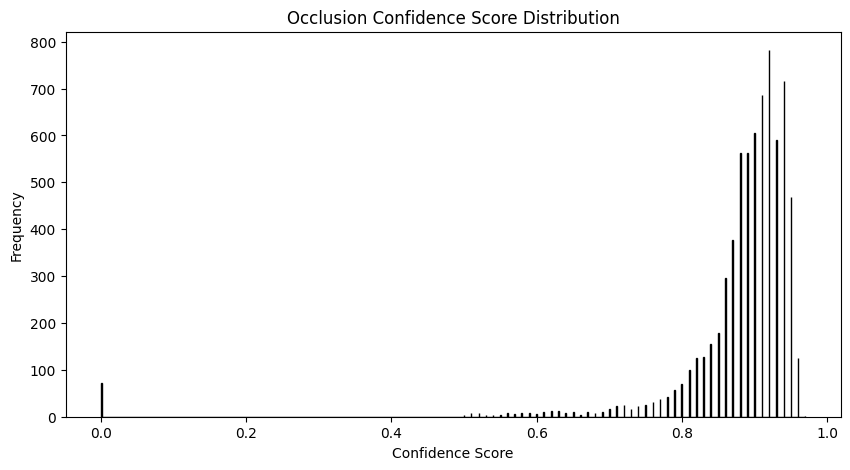

Suggested occlusion threshold (10th percentile): 0.82


In [18]:
import os
# path to extracted faces
path_to_extracted = os.path.join(data_folder_path, video_file[:-4], "faces")

# compute occlusion score for each frame
for key in dictionary_frame_to_embedding.keys():
    image_path = os.path.join(path_to_extracted, key)
    precompute_obstruction(image_path)

print("Total frames processed:", len(precomputed_obstruction))

# collect occlusion scores
occ_perc_list = []

for key in precomputed_obstruction:
    occ_perc_list.append(precomputed_obstruction[key])

# replace None values with 0
occ_perc_list_all = [0 if item is None else item for item in occ_perc_list]

# plot histogram
plt.figure(figsize=(10,5))
plt.hist(occ_perc_list_all, bins=1000, color='skyblue', edgecolor='black')
plt.title("Occlusion Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

# compute threshold
threshold_occ_perc = np.percentile(occ_perc_list_all, 10)

print("Suggested occlusion threshold (10th percentile):", threshold_occ_perc)

##### Clustering

In [19]:
X, new_frame_list = get_embedding_2D_array(dictionary_frame_to_embedding)
print(len(X))

6362


In [20]:
thres, lab = NoiseRemoval(X,3,5,0.01,5,0.001)
print(thres, lab)

0.3970000000000003 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [21]:
save_stage1_rejects(new_frame_list, lab, video_file, temp_folder_path)

In [22]:
print(new_frame_list)

['frame1002face2.jpg', 'frame1004face2.jpg', 'frame1007face1.jpg', 'frame1008face2.jpg', 'frame1009face1.jpg', 'frame100face2.jpg', 'frame100face3.jpg', 'frame1010face1.jpg', 'frame1011face1.jpg', 'frame1012face1.jpg', 'frame1013face2.jpg', 'frame1014face2.jpg', 'frame1015face2.jpg', 'frame1016face2.jpg', 'frame1017face2.jpg', 'frame1018face2.jpg', 'frame1019face2.jpg', 'frame101face2.jpg', 'frame101face3.jpg', 'frame1020face2.jpg', 'frame1021face2.jpg', 'frame1022face2.jpg', 'frame1024face2.jpg', 'frame1025face2.jpg', 'frame1026face3.jpg', 'frame1027face3.jpg', 'frame1028face3.jpg', 'frame1029face2.jpg', 'frame102face2.jpg', 'frame102face3.jpg', 'frame103face2.jpg', 'frame103face3.jpg', 'frame104face2.jpg', 'frame104face3.jpg', 'frame105face2.jpg', 'frame105face3.jpg', 'frame106face2.jpg', 'frame106face3.jpg', 'frame107face2.jpg', 'frame107face3.jpg', 'frame108face2.jpg', 'frame108face3.jpg', 'frame109face2.jpg', 'frame109face3.jpg', 'frame10face4.jpg', 'frame110face2.jpg', 'frame110f

In [23]:
filtered = [(X[i], new_frame_list[i]) for i in range(len(X)) if lab[i] != 0]

if filtered:
    X_filtered, frame_list_filtered = list(zip(*filtered))
    X_filtered = list(X_filtered)
    frame_list_filtered = list(frame_list_filtered)
else:
    X_filtered, frame_list_filtered = [], []

print(len(X_filtered))
print(len(frame_list_filtered))

6045
6045


In [24]:
X = X_filtered
new_frame_list = frame_list_filtered

In [25]:
db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(X)
labels = db.labels_

print(np.unique(labels))

if len(set(labels)) > 1 and -1 not in set(labels):
    sc = metrics.silhouette_score(X, labels)
    print("Silhouette Score:%0.2f" % sc)
else:
    print("Silhouette Score: not defined (only one cluster or noise)")

print(len(np.unique(labels)) - 1)

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Silhouette Score: not defined (only one cluster or noise)
16


In [26]:
# df_min_intercluster = check_cluster_overlap(X, labels)

# min_dist_df = df_min_intercluster.applymap(lambda x: x[1] if isinstance(x, list) else None)

# csv_filename = "cluster_min_distances.csv"

# min_dist_df.to_csv(csv_filename, index=True)

# if 'sc' in globals():
#     print("Silhouette Score:%0.2f" % sc)
# else:
#     print("Silhouette Score: not defined")

# print("Min separation:%0.2f" % min_except_diagonal(min_dist_df))

In [27]:
dict_label_to_file = get_dict_label_to_file(labels, new_frame_list)
save_clusters(labels, dict_label_to_file, video_file, eps, min_samples, metric, clusters_folder_path, "DBSCAN")

In [28]:
saved_folder_name = video_file[:-4] + '_DBSCAN_' + metric + '_' + str(eps) + '_' + str(min_samples)
print(saved_folder_name)

2026_04_06_09_10_28_DBSCAN_correlation_0.28_11


In [29]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize



def estimate_eps(X, min_samples=5, metric='cosine'):
    
    # convert to numpy array
    #X = normalize(X)
    X = np.array(X)

    # compute nearest neighbors
    neigh = NearestNeighbors(
        n_neighbors=min_samples,
        metric=metric,
        n_jobs=-1
    )

    neigh.fit(X)

    distances, indices = neigh.kneighbors(X)

    # distance to k-th neighbor
    k_distances = distances[:, min_samples-1]

    # sort
    k_distances = np.sort(k_distances)

    # plot
    plt.figure(figsize=(8,4))
    plt.plot(k_distances)
    plt.title("k-distance graph")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{min_samples}-NN distance")
    plt.grid(True)
    plt.show()

    return k_distances

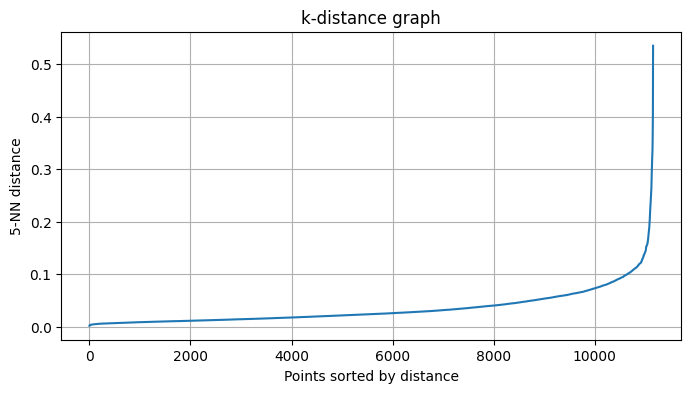

In [30]:
k_distances = estimate_eps(X, min_samples=5, metric='correlation')

#### Grid Search

In [26]:
import os
from sklearn import metrics
import pandas as pd
import numpy as np

metricss_all_ = ['correlation']
dict_metrics_start_stop = {}
face_folder_path = r"E:\Mahesh_MTP\data\ES_data\02_03_2026\2026_03_02_09_36_57\faces"
face1_list = ["frame1539face1.jpg","frame1632face1.jpg","frame1633face1.jpg","frame1635face1.jpg","frame1565face1.jpg",
              "frame1540face1.jpg","frame1631face1.jpg","frame1634face1.jpg","frame1562face1.jpg","frame1566face2.jpg",
              "frame1541face1.jpg","frame1542face1.jpg","frame1563face1.jpg","frame1564face1.jpg","frame1567face2.jpg",
              "frame1568face2.jpg","frame1830face2.jpg","frame1831face2.jpg","frame1832face2.jpg","frame1833face2.jpg",
              "frame7753face2.jpg","frame7734face2.jpg","frame7741face2.jpg","frame7742face2.jpg","frame7748face2.jpg"]
face2_list = ["frame5215face4.jpg","frame5207face3.jpg","frame5239face1.jpg","frame5230face1.jpg","frame5196face1.jpg",
              "frame5193face1.jpg","frame5190face1.jpg","frame5156face1.jpg","frame5153face1.jpg","frame5150face1.jpg",
              "frame5072face2.jpg","frame5073face2.jpg","frame5074face2.jpg","frame7052face4.jpg","frame7064face2.jpg",
              "frame7065face4.jpg","frame7066face4.jpg","frame7092face6.jpg","frame7453face3.jpg","frame7083face5.jpg",
              "frame7053face3.jpg","frame7655face3.jpg","frame7086face4.jpg","frame7059face3.jpg","frame7050face2.jpg"]
face1_paths = [os.path.join(face_folder_path, file) for file in face1_list]
face2_paths = [os.path.join(face_folder_path, file) for file in face2_list]

# Get embeddings (assuming this function exists)
face1_embeddings = {}
face2_embeddings = {}
for path in face1_paths:
    embedding = get_embedding_for_single_face(path, MTCNN, VGG)
    face1_embeddings[path] = embedding
for path in face2_paths:
    embedding = get_embedding_for_single_face(path, MTCNN, VGG)
    face2_embeddings[path] = embedding

# Create DataFrames
face1_df = pd.DataFrame(columns=face1_list, index=face1_list)
face2_df = pd.DataFrame(columns=face2_list, index=face2_list)
face12_df = pd.DataFrame(columns=face2_list, index=face1_list)

for metricc in metricss_all_:
    mini = 10000
    maxi = 10000
    
    # Process face1 comparisons
    for path in face1_paths:
        embedding = np.array(face1_embeddings[path])
        for path1 in face1_paths:
            embedding1 = np.array(face1_embeddings[path1])
            # FIXED: Use os.path.basename instead of rfind
            facea = os.path.basename(path)
            faceb = os.path.basename(path1)
            metric = metricc
            distance = metrics.pairwise_distances(embedding.reshape((1,-1)), embedding1.reshape((1,-1)), metric)
            face1_df[facea][faceb] = distance[0][0]
            if distance[0][0] != 0:
                mini = min(mini, distance[0][0])

    # Process face2 comparisons
    for path in face2_paths:
        embedding = np.array(face2_embeddings[path])
        for path1 in face2_paths:
            embedding1 = np.array(face2_embeddings[path1])
            # FIXED: Use os.path.basename instead of rfind
            facea = os.path.basename(path)
            faceb = os.path.basename(path1)
            metric = metricc
            distance = metrics.pairwise_distances(embedding.reshape((1,-1)), embedding1.reshape((1,-1)), metric)
            face2_df[facea][faceb] = distance[0][0]

    # Process cross-face comparisons
    for path in face1_paths:
        embedding = np.array(face1_embeddings[path])
        for path1 in face2_paths:
            embedding1 = np.array(face2_embeddings[path1])
            # FIXED: Use os.path.basename instead of rfind
            facea = os.path.basename(path)
            faceb = os.path.basename(path1)
            metric = metricc
            distance = metrics.pairwise_distances(embedding.reshape((1,-1)), embedding1.reshape((1,-1)), metric)
            face12_df[faceb][facea] = distance[0][0]
            if distance[0][0] != 0:
                maxi = min(maxi, distance[0][0])
    
    dict_metrics_start_stop[metricc] = (mini, maxi)

# Convert dataframe values to numeric
same_vals = face1_df.astype(float).values
diff_vals = face12_df.astype(float).values

# remove diagonal from same-person matrix
same_vals = same_vals[~np.eye(same_vals.shape[0],dtype=bool)]

max_same = np.max(same_vals)
min_diff = np.min(diff_vals)

eps = (max_same + min_diff) / 2

print("Max same-person distance:", max_same)
print("Min different-person distance:", min_diff)
print("Suggested eps:", eps)


1/1 [==============================] - 0s 31ms/step
Max same-person distance: 0.9316287114020074
Min different-person distance: 0.5515273530886728
Suggested eps: 0.7415780322453401


In [ ]:
csv_file_path = r"E:\DIPSER\gridsearch.csv"
data_list_for_grid = []
metric_list = metricss_all_

start_minS = 3
step_minS = 1
stop_minS = 12
for metricc in metric_list:
    (start_eps, stop_eps) = (0.15, 0.75)
    print(metricc)
    print(start_eps, stop_eps)
    for epss in np.linspace(start=start_eps, stop=stop_eps, num=10):
        for  minS in range(start_minS, stop_minS, step_minS):
            dbsc = DBSCAN(eps=epss, min_samples=minS, metric=metricc).fit(X)
            labelss = dbsc.labels_
            if len(np.unique(labelss))<2:
                continue
            sc = metrics.silhouette_score(X, labelss)
            db = metrics.davies_bouldin_score(X, labelss)
            ch = metrics.calinski_harabasz_score(X, labelss)
            row = [metricc, epss, minS, sc, db, ch]
            print(row)
            data_list_for_grid.append(row)
grid_search_df = pd.DataFrame(data_list_for_grid, columns=['metric', 'eps', 'minS', 'SC', 'DB', 'DH'])
grid_search_df.to_csv(os.path.join(csv_file_path), index=False)

correlation
0.15 0.75
['correlation', 0.15, 3, 0.37098206954559626, 1.142821412988277, 354.9618581306304]
['correlation', 0.15, 4, 0.3713507262811072, 1.3377593845192577, 372.42549202430547]
['correlation', 0.15, 5, 0.3724760857614056, 1.407852718759118, 399.03176536827755]
['correlation', 0.15, 6, 0.37123060989493456, 1.4399623183850125, 424.50157681753524]
['correlation', 0.15, 7, 0.37625583149184677, 1.4495198210182636, 433.5073722860236]
['correlation', 0.15, 8, 0.3790665074987917, 1.4787579356576834, 456.4431459300778]
['correlation', 0.15, 9, 0.3822416388349261, 1.494171865300168, 477.526829446359]
['correlation', 0.15, 10, 0.38092488024153925, 1.511168766473733, 486.4209101583641]
['correlation', 0.15, 11, 0.375070451366474, 1.5170145678113294, 487.8269704002866]
['correlation', 0.21666666666666667, 3, 0.3681415188947854, 1.1687195791203038, 391.3328139973162]
['correlation', 0.21666666666666667, 4, 0.37028172759838246, 1.2362893208679973, 403.96820149834923]
['correlation', 0.2

In [5]:
import pandas as pd
csv_file_path = "E:\DIPSER\gridsearch.csv"
grid_search_df = pd.read_csv(csv_file_path)
print(grid_search_df)

         'metric'     'eps'   'minS'      'SC'      'DB'        'DH'
0   'correlation'  0.150000        3  0.370982  1.142821  354.961858
1   'correlation'  0.150000        4  0.371351  1.337759  372.425492
2   'correlation'  0.150000        5  0.372476  1.407853  399.031765
3   'correlation'  0.150000        6  0.371231  1.439962  424.501577
4   'correlation'  0.150000        7  0.376256  1.449520  433.507372
5   'correlation'  0.150000        8  0.379067  1.478758  456.443146
6   'correlation'  0.150000        9  0.382242  1.494172  477.526829
7   'correlation'  0.150000       10  0.380925  1.511169  486.420910
8   'correlation'  0.150000       11  0.375070  1.517015  487.826970
9   'correlation'  0.216667        3  0.368142  1.168720  391.332814
10  'correlation'  0.216667        4  0.370282  1.236289  403.968201
11  'correlation'  0.216667        5  0.370474  1.408593  430.700094
12  'correlation'  0.216667        6  0.373614  1.510365  478.354736
13  'correlation'  0.216667       

In [6]:
max_sc_row = grid_search_df['SC'].idxmax()
row_with_max_sc = grid_search_df.loc[max_sc_row]
print(row_with_max_sc)

KeyError: 'SC'

In [3]:
!python -m tf2onnx.convert --saved-model "E:\DIPSER\Models\temp_tf_model" --output "E:\DIPSER\Models\engagement_single_attention.onnx"

I0000 00:00:1773403576.894181   44016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773403581.835378   44016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

2026-03-13 17:36:26,881 - WARNING - From c:\Users\gpuuser2\Anaconda3\envs\dipser_train\lib\site-packages\tf2onnx\tf_loader.py:190: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-03-13 17:36:26,885 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-03-13 17:36:27,024 - INFO - Signatures found in model: [serve,serving_default].
2026-03-13 17:36:27,024 - W

In [1]:
# ==========================================
# STAGE 0: INITIALIZE AI MODELS
# ==========================================
print("⏳ STAGE 0: Loading EmotiEffLib AI Models...")
import torch
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

# Auto-detect GPU to make processing significantly faster
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# We MUST use "torch". The PyTorch wrapper correctly extracts the 1280-dim features!
fer = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_afew", device=device)
print(f"✅ AI Models Loaded Successfully on {device.upper()}!")

⏳ STAGE 0: Loading EmotiEffLib AI Models...


c:\Users\gpuuser2\Anaconda3\envs\dipser_train\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ AI Models Loaded Successfully on CUDA!


In [2]:
import tensorflow as tf
import tf2onnx
from emotiefflib.engagement_classification_model import get_engagement_model
import shutil

print("⏳ Step 1: Building the Keras model directly...")
engagement_model = get_engagement_model(feature_vector_dim=2560, number_of_frames=128)

print("\n⚙️ Step 2: Saving as a raw TensorFlow SavedModel...")
# Using .export() instead of .save() to satisfy Keras 3 requirements
temp_model_dir = r"E:\DIPSER\Models\temp_tf_model"
engagement_model.export(temp_model_dir)

print("\n⚙️ Step 3: Converting pure TensorFlow to ONNX...")
onnx_model_path = r"E:\DIPSER\Models\engagement_single_attention.onnx"

# Convert from the exported SavedModel directory
model_proto, _ = tf2onnx.convert.from_saved_model(temp_model_dir, output_path=onnx_model_path)

print(f"🎉 SUCCESS! The complete ONNX model is saved as: {onnx_model_path}")

# Optional: Clean up the temporary folder to save space
try:
    shutil.rmtree(temp_model_dir)
except Exception as e:
    pass

⏳ Step 1: Building the Keras model directly...

⚙️ Step 2: Saving as a raw TensorFlow SavedModel...
INFO:tensorflow:Assets written to: E:\DIPSER\Models\temp_tf_model\assets


INFO:tensorflow:Assets written to: E:\DIPSER\Models\temp_tf_model\assets


Saved artifact at 'E:\DIPSER\Models\temp_tf_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 2560), dtype=tf.float32, name='image_set')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2185515559120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2185515564048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2185515808576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2185515809280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2185515796784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2185574732144: TensorSpec(shape=(), dtype=tf.resource, name=None)

⚙️ Step 3: Converting pure TensorFlow to ONNX...


AttributeError: module 'tf2onnx.convert' has no attribute 'from_saved_model'

#### Attention excel 

In [1]:
import os
import re
import cv2
import json
import numpy as np
import pandas as pd
from collections import Counter
import xlsxwriter
import torch
import onnxruntime as ort

# ==========================================
# STAGE 0: INITIALIZE AI MODELS
# ==========================================
print("⏳ STAGE 0: Loading AI Models...")
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load PyTorch AFEW for Emotion & Feature Extraction
fer = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_afew", device=device)

# 2. Load the Custom ONNX Engagement Model (Bypassing TensorFlow completely!)
eng_model_path = r"E:\DIPSER\Models\engagement_single_attention.onnx"
eng_session = ort.InferenceSession(eng_model_path)

print(f"✅ AI Models Loaded Successfully on {device.upper()}!")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
CLUSTER_ROOT = r"E:\Mahesh_MTP\clusterfiles\ES_clusterfiles\clusterfiles_VGG_model\06_04_2026"
EMBED_ROOT = r"E:\Mahesh_MTP\temp\embeddings\ES_embeddings\embeddings_VGG_model\06_04_2026"
OUTPUT_EXCEL = r"E:\DIPSER\Results\06_04_2026_0.58mineMaster_Report_Final.xlsx"

# Your tried-and-true threshold
MATCH_THRESHOLD = 0.58

# ==========================================
# STAGE 1: LOAD & RE-IDENTIFY (ORIGINAL GREEDY MATCHING)
# ==========================================
print("\n🔍 STAGE 1: Scanning Videos and Re-Identifying Students (Original Logic)...")
video_folders = sorted([f for f in os.listdir(CLUSTER_ROOT) if os.path.isdir(os.path.join(CLUSTER_ROOT, f))])

global_classroom = {}
student_counter = 1
all_video_times = []

for video_dir in video_folders:
    parts = video_dir.split("_")
    time_str = f"{parts[3]}:{parts[4]}:{parts[5]}"
    all_video_times.append(time_str)
    
    base_video_name = "_".join(parts[:6]) 
    embed_file = os.path.join(EMBED_ROOT, base_video_name, "embeddings_dict.json")
    
    if not os.path.exists(embed_file):
        continue
        
    with open(embed_file, "r") as f:
        embeddings_dict = json.load(f)

    full_cluster_path = os.path.join(CLUSTER_ROOT, video_dir)
    for cluster_id in os.listdir(full_cluster_path):
        if cluster_id == "-1": 
            continue 

        cluster_path = os.path.join(full_cluster_path, cluster_id)
        if not os.path.isdir(cluster_path): continue
            
        images = [img for img in os.listdir(cluster_path) if img.endswith(".jpg")]
        if not images: continue
            
        images.sort(key=lambda x: int(re.search(r'frame(\d+)', x).group(1)))
        
        valid_embs = [embeddings_dict[img] for img in images if img in embeddings_dict and embeddings_dict[img] is not None]
        if not valid_embs: continue
            
        # Your original, highly effective mean aggregation
        cluster_sig = np.mean(valid_embs, axis=0)
        cluster_sig = cluster_sig / np.linalg.norm(cluster_sig)
        
        best_match_id = None
        highest_sim = -1.0
        
        for sid, sdata in global_classroom.items():
            sim = np.dot(cluster_sig, sdata["signature"])
            if sim > highest_sim:
                highest_sim = sim
                best_match_id = sid
                
        if highest_sim >= MATCH_THRESHOLD and best_match_id is not None:
            # Match found! Blend their signature slightly and append timeline
            matched_id = best_match_id
            blended_sig = (global_classroom[matched_id]["signature"] + cluster_sig) / 2
            global_classroom[matched_id]["signature"] = blended_sig / np.linalg.norm(blended_sig)
        else:
            # Brand new student
            matched_id = f"Student_{student_counter}"
            student_counter += 1
            global_classroom[matched_id] = {
                "signature": cluster_sig,
                "timeline": {}
            }
            
        global_classroom[matched_id]["timeline"][time_str] = {
            "image_paths": [os.path.join(cluster_path, img) for img in images]
        }

print(f"✅ Found {len(global_classroom)} unique students across {len(video_folders)} videos.")

# ==========================================
# STAGE 2: AI PREDICTIONS (BULLETPROOF ONNX BYPASS)
# ==========================================
print("\n🧠 STAGE 2: Running Custom ONNX Predictions...")
temp_face_folder = "temp_excel_faces_final"
os.makedirs(temp_face_folder, exist_ok=True)

for sid, sdata in global_classroom.items():
    for time_str, tdata in sdata["timeline"].items():
        paths = tdata["image_paths"]
        
        frames_bgr = [cv2.imread(p) for p in paths]
        frames_bgr = [f for f in frames_bgr if f is not None]
        
        if len(frames_bgr) < 5:
            continue 
            
        if len(frames_bgr) > 150:
            indices = np.linspace(0, len(frames_bgr) - 1, 150, dtype=int)
            sampled_bgr = [frames_bgr[i] for i in indices]
        else:
            sampled_bgr = frames_bgr
            
        frames_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in sampled_bgr]
        
        # A. Emotion Prediction
        try:
            emo_list, _ = fer.predict_emotions(frames_rgb)
            if emo_list:
                final_emotion = Counter(emo_list).most_common(1)[0][0]
            else:
                final_emotion = "Not Detected"
        except Exception as e:
            print(f"⚠️ Emotion error for {sid} at {time_str}: {e}")
            final_emotion = "Error"
            
        # B. Engagement Prediction (Direct ONNX Integration)
        try:
            features = fer.extract_features(frames_rgb)
            
            if features is None or len(features) == 0:
                final_engagement = "Not Detected"
            else:
                # Force exact 128 length
                if len(features) < 128:
                    pad_len = 128 - len(features)
                    padding = np.repeat(features[-1:], pad_len, axis=0)
                    x = np.concatenate((features, padding), axis=0)
                elif len(features) > 128:
                    indices = np.linspace(0, len(features) - 1, 128, dtype=int)
                    x = features[indices]
                else:
                    x = features
                    
                # Construct 2560 vector
                mean_x = np.mean(x, axis=0, keepdims=True)
                mean_x_repeated = np.repeat(mean_x, 128, axis=0)
                features_2560 = np.concatenate((mean_x_repeated, x), axis=1) 
                
                # Predict
                input_data = np.expand_dims(features_2560, axis=0).astype(np.float32) 
                scores = eng_session.run(["output_0"], {"image_set": input_data})[0]
                eng_idx = np.argmax(scores[0])
                final_engagement = "Engaged" if eng_idx == 1 else "Distracted"
                
        except Exception as e:
            print(f"⚠️ Engagement error for {sid} at {time_str}: {e}")
            final_engagement = "Error"
            
        # C. Save representative face for Excel
        mid_idx = len(frames_bgr) // 2
        best_face = cv2.resize(frames_bgr[mid_idx], (90, 90))
        safe_time = time_str.replace(":", "_")
        face_path = os.path.abspath(os.path.join(temp_face_folder, f"{sid}_{safe_time}.jpg"))
        cv2.imwrite(face_path, best_face)
        
        tdata["emotion"] = final_emotion
        tdata["engagement"] = final_engagement
        tdata["rep_image"] = face_path

# ==========================================
# STAGE 3: EXCEL GENERATION
# ==========================================
print("\n📊 STAGE 3: Building Master Excel Matrix...")
excel_data = []

sorted_times = sorted(list(set(all_video_times)))

for sid, sdata in global_classroom.items():
    row = {"Student ID": sid}
    
    for t in sorted_times:
        if t in sdata["timeline"] and "engagement" in sdata["timeline"][t]:
            tdata = sdata["timeline"][t]
            row[f"{t} ImagePath"] = tdata["rep_image"] 
            row[f"{t} Image"] = "" 
            row[f"{t} Engagement"] = tdata["engagement"]
            row[f"{t} Emotion"] = tdata["emotion"]
        else:
            row[f"{t} ImagePath"] = None
            row[f"{t} Image"] = "Not Present"
            row[f"{t} Engagement"] = "-"
            row[f"{t} Emotion"] = "-"
            
    excel_data.append(row)

df = pd.DataFrame(excel_data)

os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
writer = pd.ExcelWriter(OUTPUT_EXCEL, engine='xlsxwriter')

columns_to_export = [col for col in df.columns if not col.endswith("ImagePath")]
df_export = df[columns_to_export]
df_export.to_excel(writer, sheet_name='Timeline', index=False)

workbook = writer.book
worksheet = writer.sheets['Timeline']

header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
absent_format = workbook.add_format({'bg_color': '#F2F2F2', 'font_color': '#A6A6A6', 'align': 'center', 'valign': 'vcenter'})
center_format = workbook.add_format({'align': 'center', 'valign': 'vcenter'})

for col_num, value in enumerate(df_export.columns.values):
    worksheet.write(0, col_num, value, header_format)

worksheet.set_column(0, 0, 15, center_format) 
col_idx = 1
for t in sorted_times:
    worksheet.set_column(col_idx, col_idx, 15, center_format) 
    worksheet.set_column(col_idx+1, col_idx+2, 18, center_format) 
    col_idx += 3

for row_num, data in enumerate(excel_data):
    row_excel = row_num + 1
    worksheet.set_row(row_excel, 70) 
    
    col_counter = 1
    for t in sorted_times:
        img_path_key = f"{t} ImagePath"
        if img_path_key in data and data[img_path_key] is not None:
            worksheet.insert_image(row_excel, col_counter, data[img_path_key], {'x_offset': 5, 'y_offset': 5})
        else:
            worksheet.write(row_excel, col_counter, "Not Present", absent_format)
        col_counter += 3

writer.close()
print(f"🎉 SUCCESS! Matrix saved to: {OUTPUT_EXCEL}")

⏳ STAGE 0: Loading AI Models...


c:\Users\gpuuser2\Anaconda3\envs\dipser_train\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ AI Models Loaded Successfully on CUDA!

🔍 STAGE 1: Scanning Videos and Re-Identifying Students (Original Logic)...
✅ Found 66 unique students across 8 videos.

🧠 STAGE 2: Running Custom ONNX Predictions...

📊 STAGE 3: Building Master Excel Matrix...
🎉 SUCCESS! Matrix saved to: E:\DIPSER\Results\06_04_2026_0.58mineMaster_Report_Final.xlsx


In [3]:
import os
import re
import json
import numpy as np
import pandas as pd
import cv2

# ============================
# CONFIG
# ============================
CLUSTER_ROOT = r"E:\Mahesh_MTP\clusterfiles\ES_clusterfiles\clusterfiles_VGG_model\06_04_2026"
EMBED_ROOT   = r"E:\Mahesh_MTP\temp\embeddings\ES_embeddings\embeddings_VGG_model\06_04_2026"
OUTPUT_EXCEL = r"E:\DIPSER\Results\FINAL_MATCH_OUTPUT_V4.xlsx"

MAX_EMBS = 50
MIN_CLUSTER_SIZE = 5
MAX_ID_EMBS = 100

P90_STRONG = 0.68
P90_WEAK   = 0.60
MEAN_TH    = 0.50

# ============================
# SIMILARITY
# ============================
def compute_similarity(A, B):
    A = np.array(A)
    B = np.array(B)

    sims = A @ B.T
    sims_flat = sims.flatten()
    sims_sorted = np.sort(sims_flat)[::-1]

    return {
        "p90": np.percentile(sims_flat, 90),
        "mean": np.mean(sims_flat),
        "top5": np.mean(sims_sorted[:5])
    }

# ============================
# LOAD + MATCHING
# ============================
video_folders = sorted([
    f for f in os.listdir(CLUSTER_ROOT)
    if os.path.isdir(os.path.join(CLUSTER_ROOT, f))
])

global_classroom = {}
student_counter = 1
all_times = []

print("🔍 Matching...")

for video_dir in video_folders:

    parts = video_dir.split("_")
    time_str = f"{parts[3]}:{parts[4]}:{parts[5]}"
    all_times.append(time_str)

    embed_file = os.path.join(
        EMBED_ROOT,
        "_".join(parts[:6]),
        "embeddings_dict.json"
    )

    if not os.path.exists(embed_file):
        continue

    with open(embed_file, "r") as f:
        embeddings_dict = json.load(f)

    cluster_path_full = os.path.join(CLUSTER_ROOT, video_dir)

    for cluster_id in os.listdir(cluster_path_full):

        if cluster_id == "-1":
            continue

        cluster_path = os.path.join(cluster_path_full, cluster_id)

        images = [img for img in os.listdir(cluster_path) if img.endswith(".jpg")]
        if len(images) < MIN_CLUSTER_SIZE:
            continue

        images.sort(key=lambda x: int(re.search(r'frame(\d+)', x).group(1)))

        valid_embs = [
            np.array(embeddings_dict[img])
            for img in images
            if img in embeddings_dict and embeddings_dict[img] is not None
        ]

        if len(valid_embs) < MIN_CLUSTER_SIZE:
            continue

        valid_embs = [e / np.linalg.norm(e) for e in valid_embs]

        if len(valid_embs) > MAX_EMBS:
            idx = np.linspace(0, len(valid_embs)-1, MAX_EMBS, dtype=int)
            valid_embs = [valid_embs[i] for i in idx]

        best_id = None
        best_sim = None

        for sid, sdata in global_classroom.items():

            existing_embs = sdata["embeddings"]

            if len(existing_embs) > MAX_EMBS:
                idx = np.linspace(0, len(existing_embs)-1, MAX_EMBS, dtype=int)
                existing_sample = [existing_embs[i] for i in idx]
            else:
                existing_sample = existing_embs

            sim = compute_similarity(valid_embs, existing_sample)

            if best_sim is None or sim["top5"] > best_sim["top5"]:
                best_sim = sim
                best_id = sid

        if best_sim is not None:
            if best_sim["p90"] > P90_STRONG:
                matched_id = best_id
            elif best_sim["p90"] > P90_WEAK and best_sim["mean"] > MEAN_TH:
                matched_id = best_id
            elif best_sim["top5"] > 0.70:
                matched_id = best_id
            else:
                matched_id = None
        else:
            matched_id = None

        if matched_id is None:
            matched_id = f"Student_{student_counter}"
            student_counter += 1
            global_classroom[matched_id] = {
                "embeddings": [],
                "timeline": {}
            }

        global_classroom[matched_id]["embeddings"].extend(valid_embs)

        if len(global_classroom[matched_id]["embeddings"]) > MAX_ID_EMBS:
            global_classroom[matched_id]["embeddings"] = \
                global_classroom[matched_id]["embeddings"][-MAX_ID_EMBS:]

        global_classroom[matched_id]["timeline"][time_str] = {
            "images": [os.path.join(cluster_path, img) for img in images]
        }

print(f"Before merging: {len(global_classroom)}")

# ============================
# 🔥 STEP 2: MERGING IDENTITIES
# ============================
print("🔗 Merging identities...")

ids = list(global_classroom.keys())
merged = {}

for i in range(len(ids)):
    if ids[i] in merged:
        continue

    for j in range(i+1, len(ids)):
        if ids[j] in merged:
            continue

        embA = global_classroom[ids[i]]["embeddings"]
        embB = global_classroom[ids[j]]["embeddings"]

        sim = compute_similarity(embA[:50], embB[:50])

        if sim["top5"] > 0.72:   # merge threshold
            # merge j into i
            global_classroom[ids[i]]["embeddings"].extend(embB)
            global_classroom[ids[i]]["timeline"].update(global_classroom[ids[j]]["timeline"])
            merged[ids[j]] = ids[i]

# remove merged ids
for k in merged:
    del global_classroom[k]

print(f"After merging: {len(global_classroom)}")

# ============================
# EXCEL (IMAGE ONLY)
# ============================
print("📊 Generating Excel...")

excel_data = []
sorted_times = sorted(list(set(all_times)))

temp_img_dir = "temp_excel_imgs"
os.makedirs(temp_img_dir, exist_ok=True)

for sid, sdata in global_classroom.items():

    row = {"Student ID": sid}

    for t in sorted_times:
        if t in sdata["timeline"]:
            img = sdata["timeline"][t]["images"]
            img_path = img[len(img)//2]

            # resize image
            img_cv = cv2.imread(img_path)
            img_cv = cv2.resize(img_cv, (80, 80))

            save_path = os.path.join(temp_img_dir, f"{sid}_{t.replace(':','_')}.jpg")
            cv2.imwrite(save_path, img_cv)

            row[t] = save_path
        else:
            row[t] = None

    excel_data.append(row)

df = pd.DataFrame(excel_data)

writer = pd.ExcelWriter(OUTPUT_EXCEL, engine='xlsxwriter')
df.to_excel(writer, index=False)

worksheet = writer.sheets['Sheet1']

for i, row in enumerate(excel_data):
    worksheet.set_row(i+1, 70)

    for j, t in enumerate(sorted_times):
        img_path = row[t]

        if img_path is not None:
            worksheet.insert_image(i+1, j+1, img_path)

writer.close()

print(f"🎉 DONE → {OUTPUT_EXCEL}")

🔍 Matching...
Before merging: 88
🔗 Merging identities...
After merging: 80
📊 Generating Excel...
🎉 DONE → E:\DIPSER\Results\FINAL_MATCH_OUTPUT_V4.xlsx


In [1]:
import os
# Force TensorFlow to use the Keras 2 legacy bridge BEFORE importing deepface
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import cv2
import json
import numpy as np
import pandas as pd
from collections import Counter
import xlsxwriter
import torch
import onnxruntime as ort
from deepface import DeepFace
from scipy.spatial.distance import cdist

# ==========================================
# STAGE 0: INITIALIZE AI MODELS & DATABASE
# ==========================================
print("⏳ STAGE 0: Loading AI Models & Student Database...")
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load EmotiEffLib (Emotion & Feature Extraction)
fer = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_afew", device=device)

# 2. Load ONNX Engagement Model (TensorFlow Bypass)
eng_model_path = r"E:\DIPSER\Models\engagement_single_attention.onnx"
eng_session = ort.InferenceSession(eng_model_path)

print(f"✅ AI Models Loaded Successfully on {device.upper()}!")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
CLUSTER_ROOT = r"E:\Mahesh_MTP\clusterfiles\ES_clusterfiles\clusterfiles_VGG_model\06_04_2026"
EMBED_ROOT = r"E:\Mahesh_MTP\temp\embeddings\ES_embeddings\embeddings_VGG_model\06_04_2026"
OUTPUT_EXCEL = r"E:\DIPSER\Results\06_04_2026_Master_Report_Final.xlsx"

# Database Paths
DB_EMBEDDINGS_PATH = r"E:\Mahesh_MTP\student_embeddings\ES_OG_Embeddings_final.json"
DB_IMAGES_FOLDER = r"E:\Mahesh_MTP\AttendanceVideos\ES_Final_database"

# Recognition Parameters
SIM_THRESHOLD = 0.68    
USE_VERIFY = True
MIN_CLUSTER_SIZE = 2
FINAL_MATCH_THRESHOLD = 0.60

# ==========================================
# UTILITY FUNCTIONS
# ==========================================
def l2_normalize_rows(mat):
    mat = np.array(mat, dtype=np.float32)
    return mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-10)

def compute_cluster_mean(cluster_embs_norm):
    mean_vec = np.mean(cluster_embs_norm, axis=0)
    return mean_vec / (np.linalg.norm(mean_vec) + 1e-10)

def verify_faces(face_path, db_path):
    try:
        res = DeepFace.verify(
            img1_path=face_path, img2_path=db_path,
            model_name="ArcFace", distance_metric="cosine",
            detector_backend="skip", enforce_detection=False
        )
        return res.get("verified", False)
    except Exception as e:
        return False

# ==========================================
# STAGE 1: ROBUST RECOGNITION & DEDUPLICATION
# ==========================================
print("\n🔍 STAGE 1: Matching Clusters using DeepFace Verification...")

# Load and Normalize Database
with open(DB_EMBEDDINGS_PATH, "r", encoding="utf-8") as f:
    db_raw = json.load(f)

db_embs = {}
for k, v in db_raw.items():
    arr = np.array(v, dtype=np.float32)
    db_embs[os.path.basename(k)] = arr / (np.linalg.norm(arr) + 1e-10)

db_keys = sorted(db_embs.keys())
db_matrix = np.vstack([db_embs[k] for k in db_keys]).astype(np.float32)
db_matrix_norm = l2_normalize_rows(db_matrix)

# Initialize global classroom with all known Roll Numbers
global_classroom = {os.path.splitext(k)[0]: {"timeline": {}} for k in db_keys}
all_video_times = []

video_folders = sorted([f for f in os.listdir(CLUSTER_ROOT) if os.path.isdir(os.path.join(CLUSTER_ROOT, f))])

for video_dir in video_folders:
    parts = video_dir.split("_")
    time_str = f"{parts[3]}:{parts[4]}:{parts[5]}"
    all_video_times.append(time_str)
    
    base_video_name = "_".join(parts[:6]) 
    embed_file = os.path.join(EMBED_ROOT, base_video_name, "embeddings_dict.json")
    if not os.path.exists(embed_file): continue
        
    with open(embed_file, "r", encoding="utf-8") as f:
        det_raw = json.load(f)
        
    det_embs = {os.path.basename(k): np.array(v, dtype=np.float32)/(np.linalg.norm(v)+1e-10) for k,v in det_raw.items()}

    matched_clusters = {}
    full_cluster_path = os.path.join(CLUSTER_ROOT, video_dir)
    
    for cname in os.listdir(full_cluster_path):
        if cname == "-1": continue 
        cpath = os.path.join(full_cluster_path, cname)
        if not os.path.isdir(cpath): continue
            
        faces = []
        for f in os.listdir(cpath):
            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and f in det_embs:
                faces.append({"file": f, "embedding": det_embs[f], "path": os.path.join(cpath, f)})
                
        if len(faces) < MIN_CLUSTER_SIZE: continue
            
        cluster_embs = np.vstack([f["embedding"] for f in faces])
        cluster_embs_norm = l2_normalize_rows(cluster_embs)
        mean_vec = compute_cluster_mean(cluster_embs_norm).reshape(1, -1)
        
        # NumPy Dot Product for lightning-fast Cosine Similarity
        sims = np.dot(db_matrix_norm, mean_vec.T).flatten()
        best_idx = int(np.argmax(sims))
        best_db = db_keys[best_idx]
        best_sim = float(sims[best_idx])
        
        # Find representative face for fallback verification
        dists = cdist(cluster_embs_norm, mean_vec, metric='cosine').flatten()
        rep_face = faces[int(np.argmin(dists))]
        
        # DeepFace Fallback
        if best_sim < SIM_THRESHOLD and USE_VERIFY:
            db_img = os.path.join(DB_IMAGES_FOLDER, best_db)
            if verify_faces(rep_face["path"], db_img):
                best_sim = 0.72 # Artificial boost for verified faces
                
        matched_clusters[cname] = {
            "best_db": best_db,
            "best_sim": best_sim,
            "all_paths": [f["path"] for f in faces]
        }

    # Deduplicate: Only keep the best matching cluster for each student
    db_best_match = {}
    for cname, info in matched_clusters.items():
        dbk = info["best_db"]
        if dbk not in db_best_match or info["best_sim"] > db_best_match[dbk]["best_sim"]:
            db_best_match[dbk] = info
            
    # Assign the winning clusters to the timeline
    for dbk, info in db_best_match.items():
        if info["best_sim"] >= FINAL_MATCH_THRESHOLD:
            roll = os.path.splitext(dbk)[0]
            # Ensure images are sorted chronologically
            sorted_paths = sorted(info["all_paths"], key=lambda x: int(re.search(r'frame(\d+)', os.path.basename(x)).group(1)))
            global_classroom[roll]["timeline"][time_str] = {"image_paths": sorted_paths}

print(f"✅ Recognition Complete! Analyzed {len(video_folders)} videos.")

# ==========================================
# STAGE 2: AI PREDICTIONS (ONNX BYPASS)
# ==========================================
print("\n🧠 STAGE 2: Running Engagement Predictions...")
temp_face_folder = "temp_excel_faces_final"
os.makedirs(temp_face_folder, exist_ok=True)

for roll, sdata in global_classroom.items():
    for time_str, tdata in sdata["timeline"].items():
        paths = tdata["image_paths"]
        
        frames_bgr = [cv2.imread(p) for p in paths]
        frames_bgr = [f for f in frames_bgr if f is not None]
        
        if len(frames_bgr) < 5: continue 
            
        if len(frames_bgr) > 150:
            indices = np.linspace(0, len(frames_bgr) - 1, 150, dtype=int)
            sampled_bgr = [frames_bgr[i] for i in indices]
        else:
            sampled_bgr = frames_bgr
            
        frames_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in sampled_bgr]
        
        try:
            emo_list, _ = fer.predict_emotions(frames_rgb)
            final_emotion = Counter(emo_list).most_common(1)[0][0] if emo_list else "Not Detected"
        except Exception as e:
            final_emotion = "Error"
            
        try:
            features = fer.extract_features(frames_rgb)
            if features is None or len(features) == 0:
                final_engagement = "Not Detected"
            else:
                if len(features) < 128:
                    pad_len = 128 - len(features)
                    padding = np.repeat(features[-1:], pad_len, axis=0)
                    x = np.concatenate((features, padding), axis=0)
                elif len(features) > 128:
                    indices = np.linspace(0, len(features) - 1, 128, dtype=int)
                    x = features[indices]
                else:
                    x = features
                    
                mean_x = np.mean(x, axis=0, keepdims=True)
                mean_x_repeated = np.repeat(mean_x, 128, axis=0)
                features_2560 = np.concatenate((mean_x_repeated, x), axis=1) 
                
                input_data = np.expand_dims(features_2560, axis=0).astype(np.float32) 
                scores = eng_session.run(["output_0"], {"image_set": input_data})[0]
                eng_idx = np.argmax(scores[0])
                final_engagement = "Engaged" if eng_idx == 1 else "Distracted"
        except Exception as e:
            final_engagement = "Error"
            
        mid_idx = len(frames_bgr) // 2
        best_face = cv2.resize(frames_bgr[mid_idx], (90, 90))
        face_path = os.path.abspath(os.path.join(temp_face_folder, f"{roll}_{time_str.replace(':', '_')}.jpg"))
        cv2.imwrite(face_path, best_face)
        
        tdata["emotion"] = final_emotion
        tdata["engagement"] = final_engagement
        tdata["rep_image"] = face_path

# ==========================================
# STAGE 3: EXCEL GENERATION
# ==========================================
print("\n📊 STAGE 3: Building Master Excel Matrix...")
excel_data = []
sorted_times = sorted(list(set(all_video_times)))

for roll, sdata in global_classroom.items():
    row = {"Roll Number": roll}
    
    for t in sorted_times:
        if t in sdata["timeline"] and "engagement" in sdata["timeline"][t]:
            tdata = sdata["timeline"][t]
            row[f"{t} ImagePath"] = tdata["rep_image"] 
            row[f"{t} Image"] = "" 
            row[f"{t} Engagement"] = tdata["engagement"]
            row[f"{t} Emotion"] = tdata["emotion"]
        else:
            row[f"{t} ImagePath"] = None
            row[f"{t} Image"] = "Not Present"
            row[f"{t} Engagement"] = "-"
            row[f"{t} Emotion"] = "-"
            
    excel_data.append(row)

df = pd.DataFrame(excel_data)

os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
writer = pd.ExcelWriter(OUTPUT_EXCEL, engine='xlsxwriter')

columns_to_export = [col for col in df.columns if not col.endswith("ImagePath")]
df_export = df[columns_to_export]
df_export.to_excel(writer, sheet_name='Timeline', index=False)

workbook = writer.book
worksheet = writer.sheets['Timeline']

header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
absent_format = workbook.add_format({'bg_color': '#F2F2F2', 'font_color': '#A6A6A6', 'align': 'center', 'valign': 'vcenter'})
center_format = workbook.add_format({'align': 'center', 'valign': 'vcenter'})

for col_num, value in enumerate(df_export.columns.values):
    worksheet.write(0, col_num, value, header_format)

worksheet.set_column(0, 0, 18, center_format) 
col_idx = 1
for t in sorted_times:
    worksheet.set_column(col_idx, col_idx, 15, center_format) 
    worksheet.set_column(col_idx+1, col_idx+2, 18, center_format) 
    col_idx += 3

for row_num, data in enumerate(excel_data):
    row_excel = row_num + 1
    worksheet.set_row(row_excel, 70) 
    
    col_counter = 1
    for t in sorted_times:
        img_path_key = f"{t} ImagePath"
        if img_path_key in data and data[img_path_key] is not None:
            worksheet.insert_image(row_excel, col_counter, data[img_path_key], {'x_offset': 5, 'y_offset': 5})
        else:
            worksheet.write(row_excel, col_counter, "Not Present", absent_format)
        col_counter += 3

writer.close()
print(f"🎉 SUCCESS! Matrix saved to: {OUTPUT_EXCEL}")

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (c:\Users\gpuuser2\Anaconda3\envs\dipser_train\lib\site-packages\google\protobuf\__init__.py)

#### Stage 2

In [1]:
import os
# Fix PyTorch memory fragmentation before importing torch
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import re
import cv2
import json
import numpy as np
import pandas as pd
from collections import Counter
import xlsxwriter
import torch
import onnxruntime as ort

# ==========================================
# STAGE 0: INITIALIZE AI MODELS
# ==========================================
print("⏳ STAGE 0: Loading AI Models...")
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load PyTorch AFEW for Emotion & Feature Extraction
fer = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_afew", device=device)

# 2. Load the Custom ONNX Engagement Model
eng_model_path = r"E:\DIPSER\Models\engagement_single_attention.onnx"
eng_session = ort.InferenceSession(eng_model_path)

print(f"✅ AI Models Loaded Successfully on {device.upper()}!")

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
CLUSTER_ROOT = r"E:\Mahesh_MTP\clusterfiles\ES_clusterfiles\clusterfiles_VGG_model\09_03_2026"
EMBED_ROOT = r"E:\Mahesh_MTP\temp\embeddings\ES_embeddings\embeddings_VGG_model\09_03_2026"
OUTPUT_EXCEL = r"E:\DIPSER\Results\09_03_2026_0.58mineMaster_Report_Final.xlsx"

MATCH_THRESHOLD = 0.58

# ==========================================
# STAGE 1: LOAD & RE-IDENTIFY (ORIGINAL GREEDY MATCHING)
# ==========================================
print("\n🔍 STAGE 1: Scanning Videos and Re-Identifying Students...")
video_folders = sorted([f for f in os.listdir(CLUSTER_ROOT) if os.path.isdir(os.path.join(CLUSTER_ROOT, f))])

global_classroom = {}
student_counter = 1
all_video_times = []

for video_dir in video_folders:
    parts = video_dir.split("_")
    time_str = f"{parts[3]}:{parts[4]}:{parts[5]}"
    all_video_times.append(time_str)
    
    base_video_name = "_".join(parts[:6]) 
    embed_file = os.path.join(EMBED_ROOT, base_video_name, "embeddings_dict.json")
    
    if not os.path.exists(embed_file):
        continue
        
    with open(embed_file, "r") as f:
        embeddings_dict = json.load(f)

    full_cluster_path = os.path.join(CLUSTER_ROOT, video_dir)
    for cluster_id in os.listdir(full_cluster_path):
        if cluster_id == "-1": 
            continue 

        cluster_path = os.path.join(full_cluster_path, cluster_id)
        if not os.path.isdir(cluster_path): continue
            
        images = [img for img in os.listdir(cluster_path) if img.endswith(".jpg")]
        if not images: continue
            
        images.sort(key=lambda x: int(re.search(r'frame(\d+)', x).group(1)))
        
        valid_embs = [embeddings_dict[img] for img in images if img in embeddings_dict and embeddings_dict[img] is not None]
        if not valid_embs: continue
            
        cluster_sig = np.mean(valid_embs, axis=0)
        cluster_sig = cluster_sig / np.linalg.norm(cluster_sig)
        
        best_match_id = None
        highest_sim = -1.0
        
        for sid, sdata in global_classroom.items():
            sim = np.dot(cluster_sig, sdata["signature"])
            if sim > highest_sim:
                highest_sim = sim
                best_match_id = sid
                
        if highest_sim >= MATCH_THRESHOLD and best_match_id is not None:
            matched_id = best_match_id
            blended_sig = (global_classroom[matched_id]["signature"] + cluster_sig) / 2
            global_classroom[matched_id]["signature"] = blended_sig / np.linalg.norm(blended_sig)
        else:
            matched_id = f"Student_{student_counter}"
            student_counter += 1
            global_classroom[matched_id] = {"signature": cluster_sig, "timeline": {}}
            
        global_classroom[matched_id]["timeline"][time_str] = {
            "image_paths": [os.path.join(cluster_path, img) for img in images]
        }

print(f"✅ Found {len(global_classroom)} unique students.")

# ==========================================
# STAGE 2: AI PREDICTIONS (MINI-BATCHED SLIDING WINDOW)
# ==========================================
print("\n🧠 STAGE 2: Running Custom ONNX Predictions (Memory-Safe Batching)...")
temp_face_folder = "temp_excel_faces_final"
os.makedirs(temp_face_folder, exist_ok=True)

BATCH_SIZE = 64 # Safe bite-size for the GPU

for sid, sdata in global_classroom.items():
    for time_str, tdata in sdata["timeline"].items():
        paths = tdata["image_paths"]
        
        frames_bgr = [cv2.imread(p) for p in paths]
        frames_bgr = [f for f in frames_bgr if f is not None]
        
        if len(frames_bgr) < 5:
            continue 
            
        # RAM Protection: Keep up to 1000 frames
        MAX_FRAMES = 1000
        if len(frames_bgr) > MAX_FRAMES:
            indices = np.linspace(0, len(frames_bgr) - 1, MAX_FRAMES, dtype=int)
            sampled_bgr = [frames_bgr[i] for i in indices]
        else:
            sampled_bgr = frames_bgr
            
        frames_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in sampled_bgr]
        
        # A. Emotion Prediction (Processed in Mini-Batches)
        try:
            full_emo_list = []
            for i in range(0, len(frames_rgb), BATCH_SIZE):
                batch = frames_rgb[i : i + BATCH_SIZE]
                emos, _ = fer.predict_emotions(batch)
                full_emo_list.extend(emos)
                
            if full_emo_list:
                final_emotion = Counter(full_emo_list).most_common(1)[0][0]
            else:
                final_emotion = "Not Detected"
        except Exception as e:
            print(f"⚠️ Emotion error for {sid} at {time_str}: {e}")
            final_emotion = "Error"
            
        # B. Feature Extraction (Processed in Mini-Batches)
        try:
            full_features_list = []
            for i in range(0, len(frames_rgb), BATCH_SIZE):
                batch = frames_rgb[i : i + BATCH_SIZE]
                feats = fer.extract_features(batch)
                if feats is not None and len(feats) > 0:
                    full_features_list.append(feats)
                    
            if not full_features_list:
                final_engagement = "Not Detected"
            else:
                features = np.concatenate(full_features_list, axis=0)
                
                # Sliding Window over the extracted features
                window_size = 128
                stride = 64
                all_window_scores = []
                windows = []
                
                if len(features) < window_size:
                    pad_len = window_size - len(features)
                    padding = np.repeat(features[-1:], pad_len, axis=0)
                    windows.append(np.concatenate((features, padding), axis=0))
                else:
                    for i in range(0, len(features) - window_size + 1, stride):
                        windows.append(features[i : i + window_size])
                    if (len(features) - window_size) % stride != 0:
                        windows.append(features[-window_size:])
                
                for x in windows:
                    mean_x = np.mean(x, axis=0, keepdims=True)
                    mean_x_repeated = np.repeat(mean_x, window_size, axis=0)
                    features_2560 = np.concatenate((mean_x_repeated, x), axis=1) 
                    
                    input_data = np.expand_dims(features_2560, axis=0).astype(np.float32) 
                    scores = eng_session.run(["output_0"], {"image_set": input_data})[0]
                    all_window_scores.append(scores[0])
                
                final_mean_scores = np.mean(all_window_scores, axis=0)
                eng_idx = np.argmax(final_mean_scores)
                final_engagement = "Engaged" if eng_idx == 1 else "Distracted"
                
        except Exception as e:
            print(f"⚠️ Engagement error for {sid} at {time_str}: {e}")
            final_engagement = "Error"
            
        # C. Save representative face
        mid_idx = len(frames_bgr) // 2
        best_face = cv2.resize(frames_bgr[mid_idx], (90, 90))
        safe_time = time_str.replace(":", "_")
        face_path = os.path.abspath(os.path.join(temp_face_folder, f"{sid}_{safe_time}.jpg"))
        cv2.imwrite(face_path, best_face)
        
        tdata["emotion"] = final_emotion
        tdata["engagement"] = final_engagement
        tdata["rep_image"] = face_path
        
        # AGGRESSIVE VRAM GARBAGE COLLECTION
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# ==========================================
# STAGE 3: EXCEL GENERATION
# ==========================================
print("\n📊 STAGE 3: Building Master Excel Matrix...")
excel_data = []

sorted_times = sorted(list(set(all_video_times)))

for sid, sdata in global_classroom.items():
    row = {"Student ID": sid}
    
    for t in sorted_times:
        if t in sdata["timeline"] and "engagement" in sdata["timeline"][t]:
            tdata = sdata["timeline"][t]
            row[f"{t} ImagePath"] = tdata["rep_image"] 
            row[f"{t} Image"] = "" 
            row[f"{t} Engagement"] = tdata["engagement"]
            row[f"{t} Emotion"] = tdata["emotion"]
        else:
            row[f"{t} ImagePath"] = None
            row[f"{t} Image"] = "Not Present"
            row[f"{t} Engagement"] = "-"
            row[f"{t} Emotion"] = "-"
            
    excel_data.append(row)

df = pd.DataFrame(excel_data)

os.makedirs(os.path.dirname(OUTPUT_EXCEL), exist_ok=True)
writer = pd.ExcelWriter(OUTPUT_EXCEL, engine='xlsxwriter')

columns_to_export = [col for col in df.columns if not col.endswith("ImagePath")]
df_export = df[columns_to_export]
df_export.to_excel(writer, sheet_name='Timeline', index=False)

workbook = writer.book
worksheet = writer.sheets['Timeline']

header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1, 'align': 'center'})
absent_format = workbook.add_format({'bg_color': '#F2F2F2', 'font_color': '#A6A6A6', 'align': 'center', 'valign': 'vcenter'})
center_format = workbook.add_format({'align': 'center', 'valign': 'vcenter'})

for col_num, value in enumerate(df_export.columns.values):
    worksheet.write(0, col_num, value, header_format)

worksheet.set_column(0, 0, 15, center_format) 
col_idx = 1
for t in sorted_times:
    worksheet.set_column(col_idx, col_idx, 15, center_format) 
    worksheet.set_column(col_idx+1, col_idx+2, 18, center_format) 
    col_idx += 3

for row_num, data in enumerate(excel_data):
    row_excel = row_num + 1
    worksheet.set_row(row_excel, 70) 
    
    col_counter = 1
    for t in sorted_times:
        img_path_key = f"{t} ImagePath"
        if img_path_key in data and data[img_path_key] is not None:
            worksheet.insert_image(row_excel, col_counter, data[img_path_key], {'x_offset': 5, 'y_offset': 5})
        else:
            worksheet.write(row_excel, col_counter, "Not Present", absent_format)
        col_counter += 3

writer.close()
print(f"🎉 SUCCESS! Matrix saved to: {OUTPUT_EXCEL}")

⏳ STAGE 0: Loading AI Models...


c:\Users\gpuuser2\Anaconda3\envs\dipser_train\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ AI Models Loaded Successfully on CUDA!

🔍 STAGE 1: Scanning Videos and Re-Identifying Students...
✅ Found 56 unique students.

🧠 STAGE 2: Running Custom ONNX Predictions (Memory-Safe Batching)...

📊 STAGE 3: Building Master Excel Matrix...
🎉 SUCCESS! Matrix saved to: E:\DIPSER\Results\09_03_2026_0.58mineMaster_Report_Final.xlsx


#### Video Creation

In [1]:
import cv2
import os
import json
import numpy as np
import pandas as pd
from deepface import DeepFace

# =========================================================
# 🔧 USER INPUTS
# =========================================================

input_video_path = r"E:\Mahesh_MTP\AttendanceVideos\ES_Attendance_videos\10_03_2026\2026_03_10_12_13_52.mp4"
embeddings_json_path = r"E:\Mahesh_MTP\temp\embeddings\ES_embeddings\embeddings_VGG_model\10_03_2026\2026_03_10_12_13_52\embeddings_dict.json"
excel_path = r"E:\DIPSER\Results\10_03_2026_mineMaster_Report_Final.xlsx"
cluster_folder_path = r"E:\Mahesh_MTP\clusterfiles\ES_clusterfiles\clusterfiles_VGG_model\10_03_2026\2026_03_10_12_13_52_DBSCAN_correlation_0.28_11"
output_video_path = r"E:\DIPSER\Results\OUTPUT_Video.mp4"

SIM_THRESHOLD = 0.5  # tune if needed

# =========================================================
# STEP 1 — LOAD EMBEDDINGS
# =========================================================

with open(embeddings_json_path, "r") as f:
    embeddings_dict = json.load(f)

# normalize embeddings
for k in embeddings_dict:
    emb = np.array(embeddings_dict[k])
    embeddings_dict[k] = emb / np.linalg.norm(emb)

print("✅ Embeddings loaded")

# =========================================================
# STEP 2 — BUILD CLUSTER CENTROIDS
# =========================================================

cluster_centroids = {}

for cluster_id in os.listdir(cluster_folder_path):
    if cluster_id == "-1":
        continue

    cluster_path = os.path.join(cluster_folder_path, cluster_id)

    if not os.path.isdir(cluster_path):
        continue

    embs = []

    for img in os.listdir(cluster_path):
        if img in embeddings_dict:
            embs.append(embeddings_dict[img])

    if len(embs) > 0:
        centroid = np.mean(embs, axis=0)
        centroid = centroid / np.linalg.norm(centroid)
        cluster_centroids[int(cluster_id)] = centroid

print(f"✅ Built {len(cluster_centroids)} cluster centroids")

# =========================================================
# STEP 3 — LOAD EXCEL (MAJORITY VOTING)
# =========================================================

df = pd.read_excel(excel_path)

cluster_labels = {}

for _, row in df.iterrows():
    sid = row["Student ID"]

    emotions = []
    engagements = []

    for col in df.columns:
        if "Emotion" in col and pd.notna(row[col]) and row[col] != "-":
            emotions.append(row[col])

        if "Engagement" in col and pd.notna(row[col]) and row[col] != "-":
            engagements.append(row[col])

    # Majority vote
    if len(emotions) > 0:
        emotion = max(set(emotions), key=emotions.count)
    else:
        emotion = "-"

    if len(engagements) > 0:
        engagement = max(set(engagements), key=engagements.count)
    else:
        engagement = "-"

    # ASSUMPTION: Student_3 → cluster 3
    try:
        cluster_id = int(str(sid).split("_")[-1])
    except:
        continue

    cluster_labels[cluster_id] = {
        "emotion": emotion,
        "engagement": engagement
    }

print("✅ Labels extracted from Excel")

# =========================================================
# STEP 4 — VIDEO PROCESSING (OPTIMIZED)
# =========================================================

import gc

FRAME_SKIP = 3          # process every 3rd frame
MAX_FACES = 8           # limit faces per frame
RESIZE_W, RESIZE_H = 640, 360

cap = cv2.VideoCapture(input_video_path)

fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

frame_id = 0

print("🎬 Processing video (optimized)...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_id += 1

    # ---- SKIP FRAMES ----
    if frame_id % FRAME_SKIP != 0:
        out.write(frame)
        continue

    # ---- RESIZE FOR FAST DETECTION ----
    small_frame = cv2.resize(frame, (RESIZE_W, RESIZE_H))

    # ---- FACE DETECTION (LIGHTWEIGHT) ----
    try:
        faces = DeepFace.extract_faces(
            img_path=small_frame,
            detector_backend='opencv',   # MUCH lighter than retinaface
            enforce_detection=False
        )
    except:
        out.write(frame)
        continue

    # ---- SCALE BACK ----
    scale_x = w / RESIZE_W
    scale_y = h / RESIZE_H

    faces = faces[:MAX_FACES]

    for face in faces:
        x = int(face['facial_area']['x'] * scale_x)
        y = int(face['facial_area']['y'] * scale_y)
        w_box = int(face['facial_area']['w'] * scale_x)
        h_box = int(face['facial_area']['h'] * scale_y)

        face_crop = frame[y:y+h_box, x:x+w_box]

        if face_crop is None or face_crop.size == 0:
            continue

        # ---- EMBEDDING ----
        try:
            emb_obj = DeepFace.represent(
                img_path=face_crop,
                model_name="VGG-Face",
                enforce_detection=False
            )

            if len(emb_obj) == 0:
                continue

            emb = np.array(emb_obj[0]['embedding'])
            emb = emb / np.linalg.norm(emb)

        except:
            continue

        # ---- MATCH ----
        best_cluster = None
        best_sim = -1

        for cid, centroid in cluster_centroids.items():
            sim = np.dot(emb, centroid)
            if sim > best_sim:
                best_sim = sim
                best_cluster = cid

        if best_sim < SIM_THRESHOLD or best_cluster is None:
            label_text = "Unknown"
        else:
            label = cluster_labels.get(best_cluster, {})
            emotion = label.get("emotion", "-")
            engagement = label.get("engagement", "-")

            label_text = f"ID {best_cluster} | {engagement} | {emotion}"

        # ---- DRAW ----
        cv2.rectangle(frame, (x, y), (x+w_box, y+h_box), (0,255,0), 2)
        cv2.putText(frame, label_text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    out.write(frame)

    # ---- CLEAN MEMORY ----
    gc.collect()

cap.release()
out.release()

print("🎉 DONE! Output saved:", output_video_path)

✅ Embeddings loaded
✅ Built 43 cluster centroids
✅ Labels extracted from Excel
🎬 Processing video (optimized)...


: 